In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg.

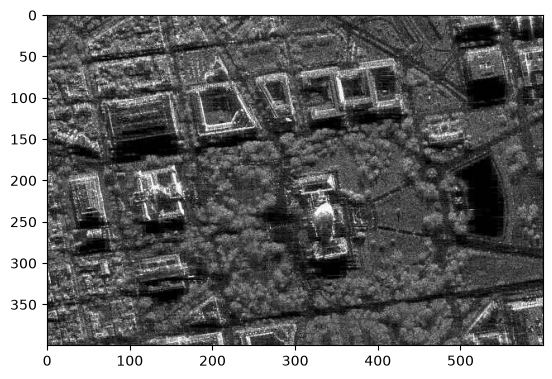

In [2]:
image = cv2.imread('sar_1_gray.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

# 2. Постройте гистограмму 

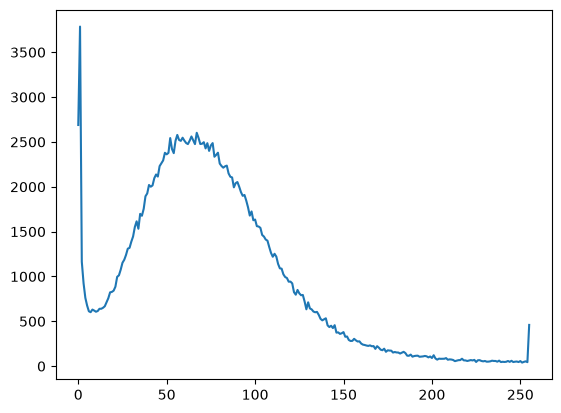

In [3]:
hist = cv2.calcHist([image_gray], [0], None, [256], [0, 256], accumulate=False)
plt.plot(hist)

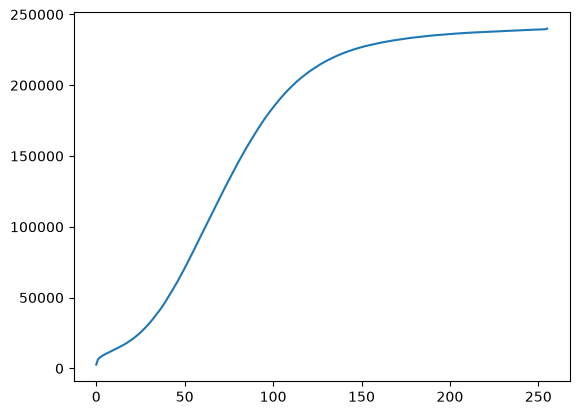

In [4]:
hist_cum = hist.cumsum()
plt.plot(hist_cum)

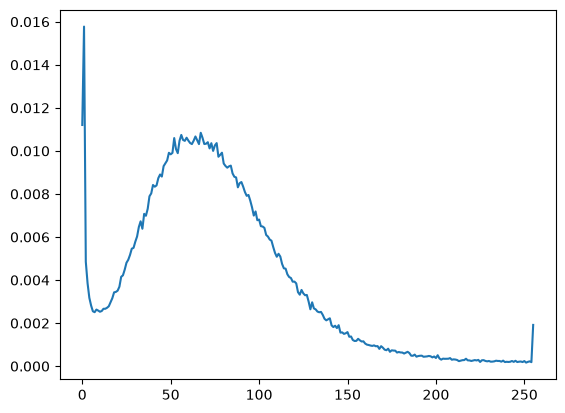

In [5]:
hist_norm = hist / (image.shape[0] * image.shape[1])
plt.plot(hist_norm)

# 3. Реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.

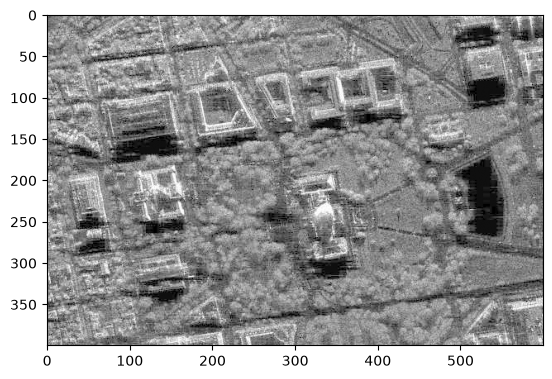

In [6]:
def gamma_correction(img, gamma):
    corrected = cv2.pow(img / 255.0, gamma)
    return (corrected * 255).astype(np.uint8)

image_light = gamma_correction(image_gray, 0.5)
plt.imshow(image_light, cmap="gray")

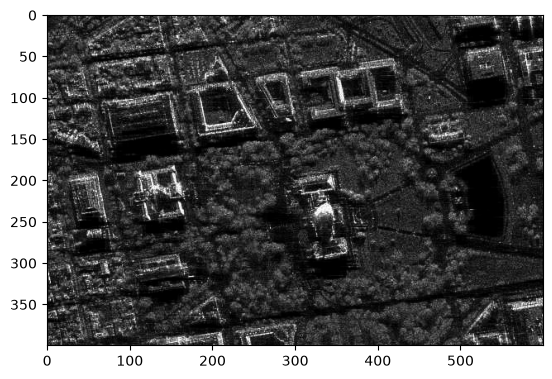

In [7]:
image_dark  = gamma_correction(image_gray, 1.5)
plt.imshow(image_dark, cmap="gray")

# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.

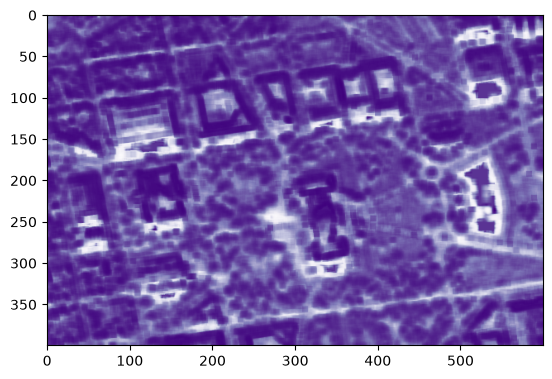

In [8]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_dark, full=True)
diff = (diff * 255).astype("uint8")
plt.imshow(diff, cmap="Purples")

In [9]:
print("SSIM: {}".format(ssim))

SSIM: 0.8065788107754002


In [10]:
mse = mean_squared_error(image_gray, image_dark)
print("MSE: {}".format(mse))

MSE: 971.8206541666667


# 5. Реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.

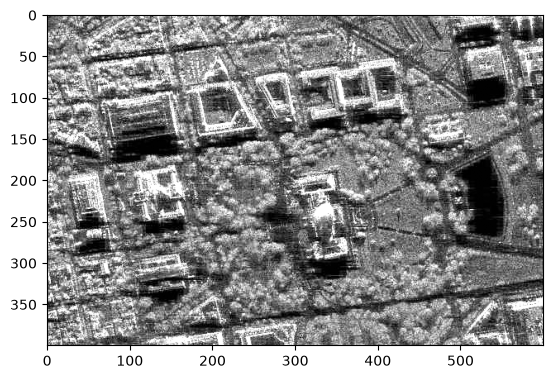

In [24]:
def color_transfer(target, source):
    E_t = target.mean()
    D_t = target.std()
    E_s = source.mean()
    D_s = source.std()
    new = E_s + (target - E_t) * (D_s / D_t)
    return np.clip(new, 0, 255).astype(np.uint8)

eq_gray = cv2.equalizeHist(image_gray)
color_transfer_image = color_transfer(image_gray, eq_gray)
plt.imshow(color_transfer_image, cmap='gray')

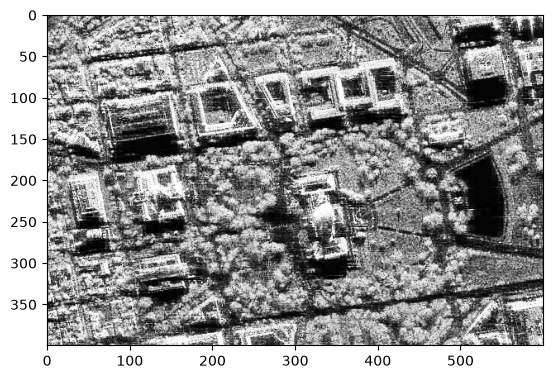

In [25]:
plt.imshow(eq_gray, cmap='gray')

# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.

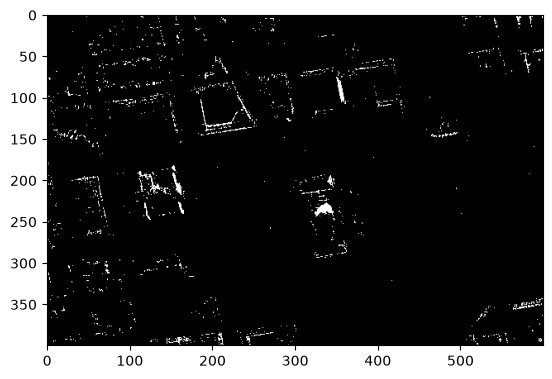

In [26]:
_, thresh1 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_BINARY)
plt.imshow(thresh1, cmap='gray')

In [27]:
thresh1[thresh1 == 100].sum()

np.uint64(0)

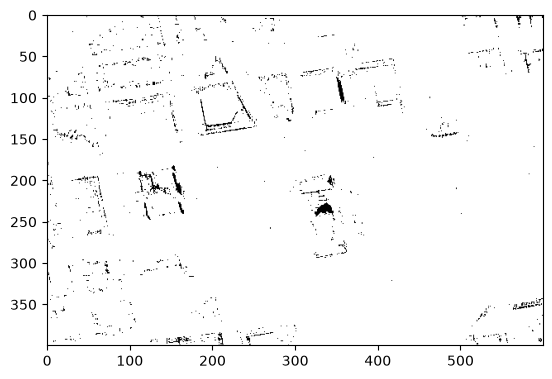

In [28]:
_, thresh2 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_BINARY_INV)
plt.imshow(thresh2, cmap='gray')

In [29]:
thresh2[thresh2 == 100].sum()

np.uint64(0)

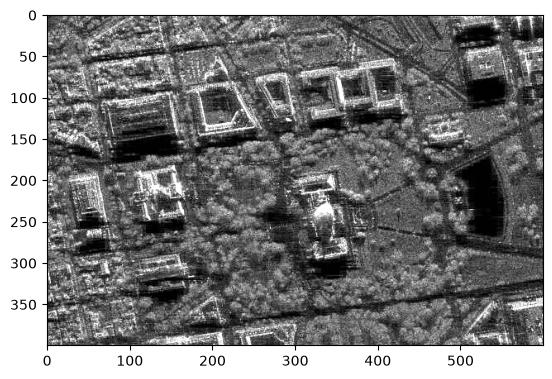

In [30]:
_, thresh3 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_TRUNC)
plt.imshow(thresh3, cmap='gray')

In [31]:
thresh3[thresh3 == 210].sum()

np.uint64(0)

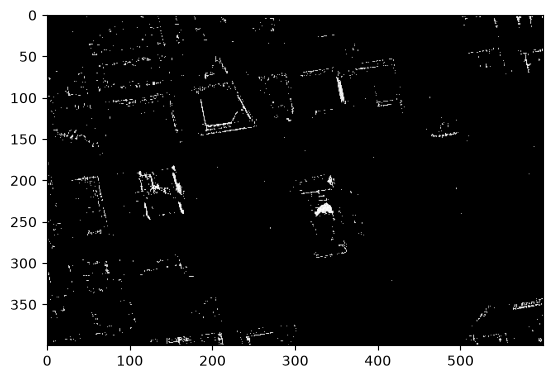

In [32]:
_, thresh4 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_TOZERO)
plt.imshow(thresh4, cmap='gray')

In [33]:
thresh4[thresh4 == 190].sum()

np.uint64(0)

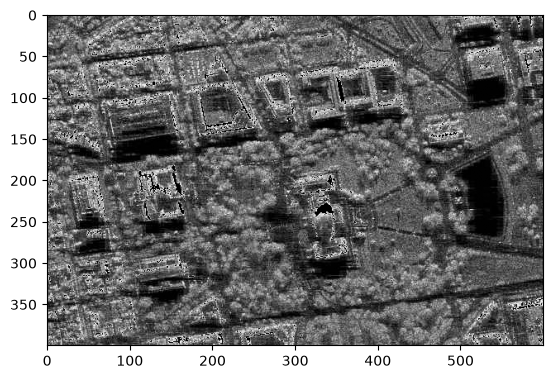

In [34]:
_, thresh5 = cv2.threshold(image_gray, 200, 255, cv2.THRESH_TOZERO_INV)
plt.imshow(thresh5, cmap='gray')

In [35]:
thresh5[thresh5 == 210].sum()

np.uint64(0)

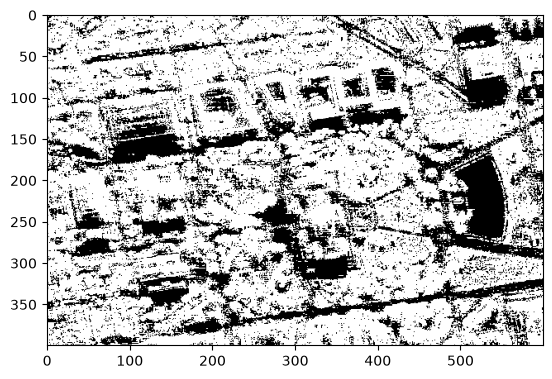

In [36]:
_, thresh6 = cv2.threshold(image_gray, 50, 255, cv2.THRESH_BINARY)
plt.imshow(thresh6, cmap='gray')